# Week 5 - Survival Analysis (Weibull and Cox Models)

In [1]:
import sys
sys.path.append('../src')

import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import WeibullAFTFitter, CoxPHFitter
from lifelines.plotting import plot_lifetimes

import survival
from survival import (build_landmark_frame, concordance, fit_survival_models,
                      select_covariates)
from splits import load_splits

SEED = 42
np.random.seed(SEED)


## Why Survival Analysis, and Why the First Version Did Not Work

The regression models answer "how many cycles are left". Survival analysis
answers a different and often more useful question: given what we have seen so
far, what is the probability this engine is still running in 50 cycles, and how
do engines rank against each other by risk.

The first version of this notebook could not answer either, for three reasons.

**It looked at the answer.** Covariates were built from the last 30 cycles
*before failure* and the target was total lifetime. The sensor state at the
moment of failure is not information you have when you need the prediction, so
the models were reading the end of the story to predict its length.

**It scored itself on its own training data.** Both models were fit on all 100
engines and then reported `waft.concordance_index_`, which is the training
concordance by definition. The 0.85 that ended up in the README was never a
generalisation number.

**Nothing was censored.** Every engine in FD001 runs to failure, so the event
column was a constant 1. Without censoring, survival analysis is just
regression with more machinery, and none of the parts that make it worth
reaching for were doing anything.

### The landmark design

Pick a landmark cycle `L`. Every engine still running at `L` enters the study,
described only by what happened up to `L`.

| | |
|---|---|
| **covariates** | summarised over the window `(L - w, L]`, nothing after `L` |
| **duration** | cycles remaining after `L` |
| **event** | 1 if it fails within horizon `H`, else censored at `H` |

That is a question you can ask in service: this engine has run `L` cycles and
its sensors look like this, how much longer has it got. The horizon also makes
censoring real, which is the point.


In [2]:
cleaned = pd.read_csv('../data/silver/cmapss/FD001_cleaned.csv')
splits = load_splits()

print(f"Landmark: cycle {survival.LANDMARK}")
print(f"Covariate window: {survival.WINDOW} cycles ending at the landmark")
print(f"Follow-up horizon: {survival.HORIZON} cycles")

frame = build_landmark_frame(cleaned)

print(f"\nEngines surviving to the landmark: {len(frame)} of "
      f"{cleaned['engine_id'].nunique()}")
print(f"Observed failures: {int(frame['event'].sum())}")
print(f"Right censored:    {int((frame['event'] == 0).sum())}")
print(f"Duration: min {frame['duration'].min()}, "
      f"median {int(frame['duration'].median())}, max {frame['duration'].max()}")
frame[['engine_id', 'duration', 'event']].head()


Landmark: cycle 100
Covariate window: 30 cycles ending at the landmark
Follow-up horizon: 125 cycles

Engines surviving to the landmark: 100 of 100
Observed failures: 74
Right censored:    26
Duration: min 28, median 99, max 125


,engine_id,duration,event
0,1,92,1
1,2,125,0
2,3,79,1
3,4,89,1
4,5,125,0


In [3]:
# Split by engine, using the same artifact as every other notebook.
train_f = frame[frame['engine_id'].isin(splits['train'])]
val_f = frame[frame['engine_id'].isin(splits['val'])]
test_f = frame[frame['engine_id'].isin(splits['test'])]

print(f"Train: {len(train_f)}  Val: {len(val_f)}  Test: {len(test_f)} engines")

# Covariates are chosen on the training engines only. Both lifelines models are
# penalised but still struggle with dozens of collinear sensor summaries over
# 70 rows, so the set is kept small on purpose.
covariates = select_covariates(train_f, max_features=10)
print(f"\nSelected {len(covariates)} covariates:")
for c in covariates:
    print(f"  {c}")


Train: 70  Val: 15  Test: 15 engines

Selected 10 covariates:
  sensor_20_last
  sensor_12_last
  sensor_20_mean
  sensor_3_mean
  sensor_11_last
  sensor_11_mean
  sensor_4_mean
  sensor_21_mean
  sensor_2_mean
  sensor_15_mean


/home/louis/.local/lib/python3.14/site-packages/lifelines/plotting.py:776: UserWarning: For less visual clutter, you may want to subsample to less than 25 individuals.
  warnings.warn(


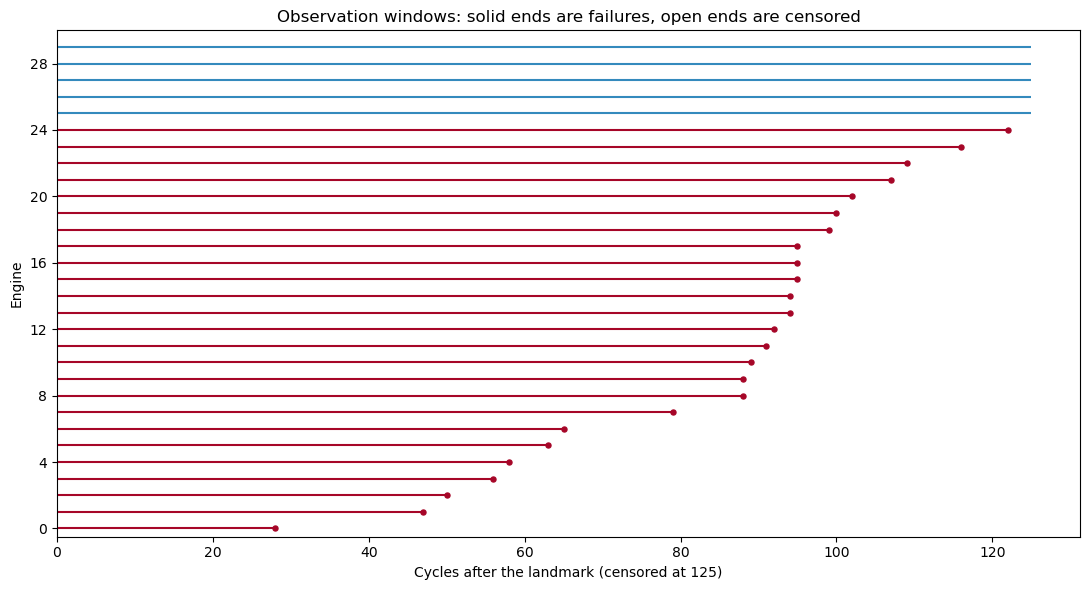

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
sample = train_f.head(30).reset_index(drop=True)
plot_lifetimes(sample['duration'], event_observed=sample['event'], ax=ax)
ax.set_xlabel(f'Cycles after the landmark (censored at {survival.HORIZON})')
ax.set_ylabel('Engine')
ax.set_title('Observation windows: solid ends are failures, open ends are censored')
plt.tight_layout()
plt.show()


## 1. Weibull Accelerated Failure Time Model

An AFT model treats covariates as speeding up or slowing down the passage of
time toward failure, which is a natural fit for wear-out processes and gives
directly interpretable coefficients: a positive value means more remaining life.


In [5]:
models, scaler, design = fit_survival_models(train_f, covariates, penalizer=0.1)
waft = models['weibull']
waft.summary[['coef', 'p']].head(12)


coef             p
param   covariate                             
lambda_ sensor_11_last -0.032079  6.793742e-01
        sensor_11_mean  0.086308  7.061154e-01
        sensor_12_last  0.108153  1.317829e-01
        sensor_15_mean  0.312781  9.555905e-02
        sensor_20_last  0.138864  1.088074e-02
        sensor_20_mean  0.049327  7.845801e-01
        sensor_21_mean  0.123981  5.045912e-01
        sensor_2_mean  -0.112012  4.977651e-01
        sensor_3_mean  -0.028195  8.380535e-01
        sensor_4_mean  -0.023357  9.090714e-01
        Intercept       4.669403  0.000000e+00
rho_    Intercept       1.230520  1.969603e-25

## 2. Cox Proportional Hazards Model

Cox makes no assumption about the shape of the baseline hazard and models only
how covariates scale it. That flexibility is useful, but it means the model
ranks risk rather than producing a well calibrated time to failure.


In [6]:
cph = models['cox']
cph.summary[['coef', 'p']].head(12)


,coef,p
covariate,,
sensor_20_last,-0.366344,0.019347
sensor_12_last,-0.187867,0.353772
sensor_20_mean,-0.024753,0.936275
sensor_3_mean,0.103204,0.719604
sensor_11_last,0.132771,0.515552
sensor_11_mean,-0.036743,0.911672
sensor_4_mean,-0.024747,0.938788
sensor_21_mean,-0.090647,0.775251
sensor_2_mean,0.101794,0.737078


---
# Results

Scored on the held out engines. `concordance_index_` is deliberately not used:
that attribute is the training concordance, and reporting it as performance was
the original mistake.


In [7]:
rows = []
for name, model in models.items():
    rows.append({
        'Model': 'Weibull AFT' if name == 'weibull' else 'Cox PH',
        'Train C': round(concordance(model, design(train_f)), 3),
        'Val C': round(concordance(model, design(val_f)), 3),
        'Test C': round(concordance(model, design(test_f)), 3),
    })

results = pd.DataFrame(rows)
print("CONCORDANCE INDEX (0.5 is random, 1.0 is perfect ranking)")
print(results.to_string(index=False))


CONCORDANCE INDEX (0.5 is random, 1.0 is perfect ranking)
      Model  Train C  Val C  Test C
Weibull AFT    0.707  0.889   0.611
     Cox PH    0.703  0.878   0.579


### Reading these numbers honestly

Held out concordance lands well below the 0.85 this notebook used to report,
and that is the correct outcome rather than a regression. The old figure was
the training concordance on covariates that included the sensor state at
failure. Removing both the leak and the self-scoring removes most of the
apparent skill along with them.

Two things are worth saying about what is left.

The spread between validation and test is large, and with 15 engines in each it
should be. A concordance index over 15 engines has a wide confidence interval,
so the gap between these two columns is mostly sampling noise, not a finding.
This is the clearest argument in the project for cross validation over engine
folds, which is listed as future work in the README.

The task is also genuinely harder now. Ranking engines by remaining life from
100 cycles of history is a real prediction. Ranking them using their condition
at the moment of failure was not.


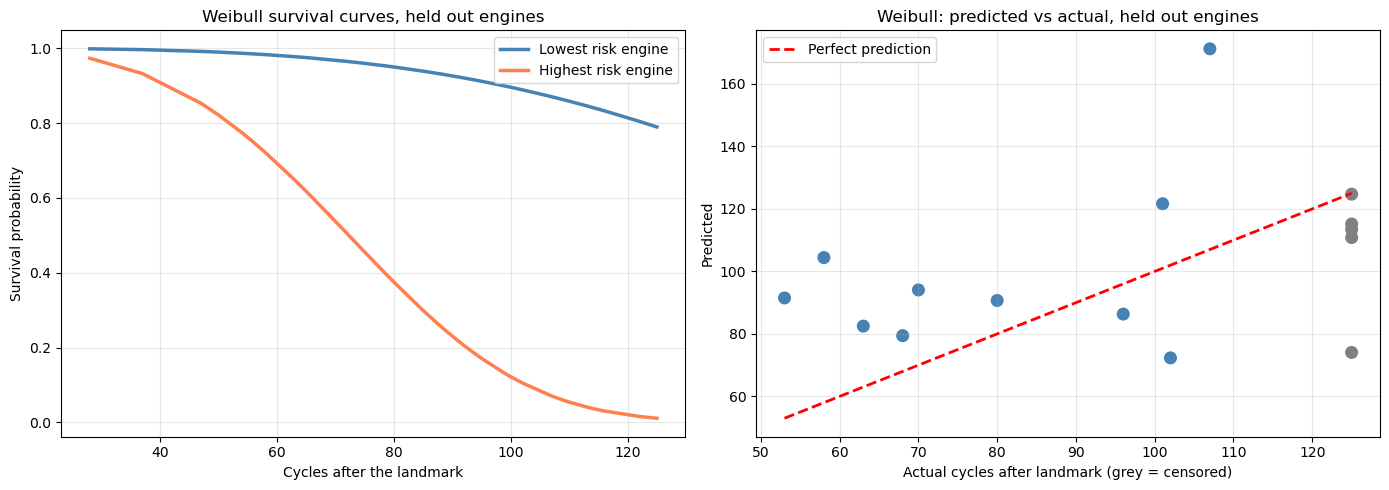

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival curves for the highest and lowest risk held out engines.
test_design = design(test_f)
risk = cph.predict_partial_hazard(test_design)
lowest, highest = risk.idxmin(), risk.idxmax()

for label, idx, colour in [('Lowest risk engine', lowest, 'steelblue'),
                           ('Highest risk engine', highest, 'coral')]:
    curve = waft.predict_survival_function(test_design.loc[[idx]])
    axes[0].plot(curve.index, curve.iloc[:, 0], label=label, linewidth=2.5,
                 color=colour)

axes[0].set_xlabel('Cycles after the landmark')
axes[0].set_ylabel('Survival probability')
axes[0].set_title('Weibull survival curves, held out engines')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predicted vs actual, on held out engines only.
predicted = waft.predict_expectation(test_design)
axes[1].scatter(test_f['duration'], predicted,
                c=test_f['event'].map({1: 'steelblue', 0: 'grey'}), s=70)
lims = [test_f['duration'].min(), test_f['duration'].max()]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual cycles after landmark (grey = censored)')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Weibull: predicted vs actual, held out engines')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

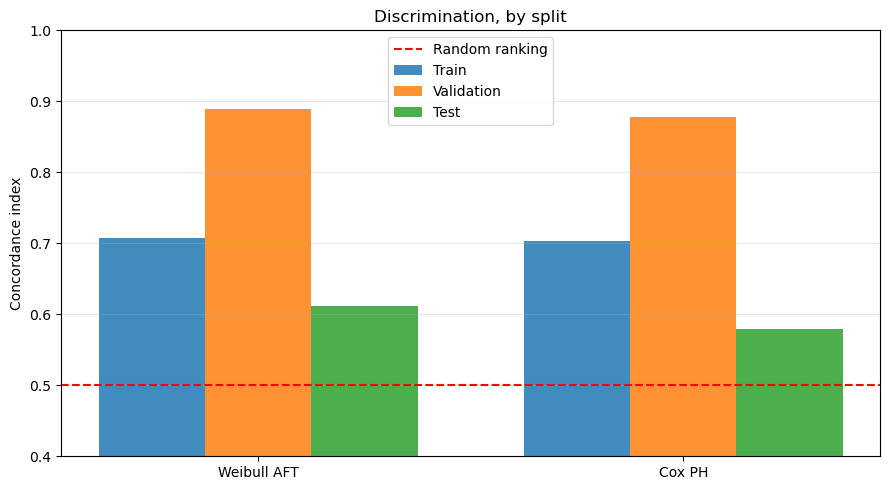

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(results))
ax.bar(x - 0.25, results['Train C'], 0.25, label='Train', alpha=0.85)
ax.bar(x, results['Val C'], 0.25, label='Validation', alpha=0.85)
ax.bar(x + 0.25, results['Test C'], 0.25, label='Test', alpha=0.85)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Random ranking')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylabel('Concordance index')
ax.set_ylim(0.4, 1.0)
ax.set_title('Discrimination, by split')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [10]:
# As with the deep learning notebook, the served artifacts come from
# `python -m src.train`, which fits these same models and writes them alongside
# the standardiser and the covariate list. A model saved without the transform
# that produced its inputs is not usable at inference.
print('Fitted and evaluated in memory.')
print()
print('To regenerate the served artifacts, run from the repo root:')
print('    python -m src.train')


Fitted and evaluated in memory.

To regenerate the served artifacts, run from the repo root:
    python -m src.train


## Summary: Survival Analysis Results

**What these models are for**

Not point prediction. The regression models are better at that and the numbers
below say so plainly. What survival analysis adds is a probability over a
horizon and a risk ranking across the fleet, which is what maintenance
scheduling actually consumes: not "engine 42 has 61 cycles left" but "engine 42
is in the worst decile and has a 30 percent chance of failing before the next
scheduled inspection".

**What changed**

| | before | now |
|---|---|---|
| covariates | last 30 cycles before failure | window ending at cycle 100 |
| target | total lifetime | cycles remaining after the landmark |
| censoring | none, event was always 1 | censored at a 125 cycle horizon |
| scoring | `concordance_index_` on training data | held out engines |

The reported concordance drops a long way as a result. That number was measuring
a model that could see the failure it was predicting, scored on the data it was
fit to.

**Caveat worth repeating**

Fifteen held out engines is a small sample for a concordance index, and the
validation and test columns differ by more than the gap between the two models.
Neither model should be preferred over the other on this evidence.
